# 12 · The in-code PCA path, across redshift

Notebook 09 checks the coefficients L-GALAXIES writes **inside the C code at output time**
against its own `Mag`, at z = 0. The multi-redshift run gives ten snapshots, so the same
check can be run at every one of them, and the redshift dependence becomes visible.

**Execution model — guarded.** This notebook reads the L-GALAXIES binary output directly,
so it needs the simulation tree. It fails at the top, naming the missing files, rather than
part-way through.

By the end you should be able to answer:

1. Does the in-code C path reproduce L-GALAXIES' own magnitudes at every snapshot, or only
   at z = 0 where it was checked?
2. Does the agreement depend on redshift, and in which direction?
3. Does the colour-mass locus of the reconstruction track the model's own at high z?

Everything is precomputed once for all ten redshifts — 1.7 s, about 4 MB of derived arrays —
so the selector below responds immediately. The raw structures are 1.9 GB in total, and are
dropped inside the loop rather than cached.

## Merger tree

In [9]:
# ── Merger tree ─────────────────────────────────────────────────────────────
# One selection, from the registry, so the binaries, the file range and the resolution
# cuts below cannot disagree about which simulation this is.
from galspectra.trees import get_tree

TREE = get_tree("MR")
print(f'Tree: {TREE.label}  ({TREE.pretty})')

Tree: MR  (Millennium-I)


In [10]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path('..').resolve()
LGAL_ROOT    = PROJECT_ROOT.parent / 'L-GALAXIES' / 'LGalaxies2020_PublicRepository-master'
LGAL_PYTHON  = LGAL_ROOT / 'AuxCode' / 'Python'
FILTER_DIR   = LGAL_ROOT / 'SpecPhotTables' / 'Filters'

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from galspectra.lgalaxies import discover_tags, snapshots
from galspectra.photometry.filters import load_sdss_filters
from galspectra.photometry.synthetic import C_ANG_S

# ── Constants, matching notebook 09 exactly so the two are comparable ──────
hub_h            = 0.673
PART_RES         = 20.0                      # particles
DM_PART_MSUNh    = TREE.dm_particle_msun_h
SM_RES_MSUN      = TREE.sm_resolution_msun
_D_10PC_CM       = 3.0857e19
_FOUR_PI_10PC_SQ = 4.0 * np.pi * _D_10PC_CM ** 2

BANDS       = ['u', 'g', 'r', 'i', 'z']
BAND_IDX    = {b: i for i, b in enumerate(BANDS)}
BAND_COLORS = {'u': '#7B2FBE', 'g': '#4CAF50', 'r': '#F44336',
               'i': '#FF9800', 'z': '#795548'}

FILE_NR = None                               # None = every file in TREE.file_range

# ── Which redshifts are on disk, and do their binaries exist? ──────────────
TAGS  = discover_tags(TREE, LGAL_ROOT)
SNAPS = {s.tag: s for s in snapshots(LGAL_ROOT, tags=TAGS)}

BINARIES = {t: TREE.output_paths(LGAL_ROOT, FILE_NR, tag=t) for t in TAGS}
missing  = [p for paths in BINARIES.values() for p in paths if not p.exists()]
if missing:
    shown = '\n    '.join(str(p) for p in missing[:6])
    raise FileNotFoundError(
        f'tree {TREE.label!r} ({TREE.pretty}) needs L-GALAXIES binary output with in-code '
        f'PCA coefficients, and {len(missing)} file(s) are missing:\n    {shown}\n'
        f'These come from a run with COMP_PCA_COEFFICIENTS enabled. If this tree\'s output '
        f'lives on an external drive, mount it.')

print(f'{len(TAGS)} redshifts on disk: {", ".join("z" + t for t in TAGS)}')
print(f'binaries per redshift: {len(next(iter(BINARIES.values())))}   '
      f'(file range {TREE.file_range.start}-{TREE.file_range.stop - 1})')

# ── The committed basis, and the filters L-GALAXIES itself used ───────────
pca        = np.load(PROJECT_ROOT / 'data' / 'pca_results_bc03.npz', allow_pickle=True)
pca_wave   = pca['wave']
pca_comps  = pca['components']
pca_mean   = pca['mean']
_norm      = pca['norm'].item()
norm_mean, norm_std = _norm['mean'], _norm['std']
filters    = load_sdss_filters(FILTER_DIR)

print(f'basis  : {pca_comps.shape[0]} components x {len(pca_wave)} bins')
print(f'filters: {", ".join(filters)}  (the same curves Mag was computed with)')

10 redshifts on disk: z0.00, z0.26, z0.51, z0.78, z1.04, z1.48, z2.07, z2.44, z3.11, z5.03
binaries per redshift: 1   (file range 5-5)
basis  : 50 components x 831 bins
filters: u, g, r, i, z  (the same curves Mag was computed with)


---

## Precomputing every redshift

The pipeline per snapshot is the one notebook 09 runs once: read the binary, apply the
resolution cuts, sum the star-formation history to get the formed mass, reconstruct the
spectrum from the **in-code** coefficients, and integrate it through *ugriz*.

`compute_ab_mag_batch` is ported verbatim from notebook 09 so that any difference between
the two notebooks is a difference in the data, never in the arithmetic.

Only the derived arrays are kept. The raw structure for one snapshot is up to 259 MB and
all ten would be 1.9 GB, so each is reduced and dropped inside the loop.

In [11]:
sys.path.insert(0, str(LGAL_PYTHON))
from LGalaxy_snapshots import LGalaxiesStruct


# The filter integrals are the same for every galaxy, so the interpolation onto the basis
# grid is done once here rather than per chunk. The arithmetic is identical to notebook
# 09's compute_ab_mag_batch -- only the loop structure differs -- so a disagreement
# between the two notebooks can never be a difference in how a magnitude was computed.
_NU     = C_ANG_S / pca_wave
_NU_IDX = np.argsort(_NU)
_NU_S   = _NU[_NU_IDX]
_FNU_FACTOR = (pca_wave ** 2 / C_ANG_S)[_NU_IDX]
_FILTER_T, _FILTER_DEN = {}, {}
for _b, (_wf, _tf) in filters.items():
    _T = np.interp(pca_wave, _wf, _tf, left=0., right=0.)[_NU_IDX]
    _FILTER_T[_b]   = _T
    _FILTER_DEN[_b] = float(np.trapezoid(_T, _NU_S))


def _mags_from_coeffs(coeffs, M_tot, chunk=2000):
    """Reconstruct and photometer in chunks, so the (N, 831) spectra never all exist.

    At 11,396 galaxies the full array is 76 MB in float64 on top of a 259 MB structure.
    That is survivable in isolation and not on a machine that is already swapping, and
    nothing here needs every spectrum at once -- only their magnitudes.
    """
    n = len(coeffs)
    out = {b: np.full(n, np.nan) for b in BANDS}
    for lo in range(0, n, chunk):
        hi = min(lo + chunk, n)
        M  = M_tot[lo:hi]
        good = M > 0
        normed = np.zeros((hi - lo, coeffs.shape[1]))
        normed[good] = coeffs[lo:hi][good] / M[good, np.newaxis]
        sed = ((pca_mean[np.newaxis, :] + normed @ pca_comps) * norm_std[np.newaxis, :]
               + norm_mean[np.newaxis, :]) * M[:, np.newaxis] / _FOUR_PI_10PC_SQ
        fnu = sed[:, _NU_IDX] * _FNU_FACTOR[np.newaxis, :]
        for b in BANDS:
            num = np.trapezoid(fnu * _FILTER_T[b][np.newaxis, :], _NU_S, axis=1)
            with np.errstate(divide='ignore', invalid='ignore'):
                out[b][lo:hi] = np.where(num > 0,
                                         -2.5 * np.log10(num / _FILTER_DEN[b]) - 48.6,
                                         np.nan)
    return out


def load_redshift(tag):
    """Everything sections 1-3 need for one snapshot, holding as little as possible.

    The selection and the column extraction happen per file and the structure is released
    immediately, so peak memory is one file's worth rather than the whole redshift.
    """
    mag, coeff, M_tot, stellar, bulge = [], [], [], [], []
    n_total = 0
    sm_cut   = SM_RES_MSUN * hub_h / 1e10          # binary units: 10^10 Msun/h
    mvir_cut = PART_RES * DM_PART_MSUNh / (1e10 / hub_h)

    for path in BINARIES[tag]:
        with open(path, 'rb') as f:
            n_trees = int(np.fromfile(f, np.int32, 1)[0])
            n_gals  = int(np.fromfile(f, np.int32, 1)[0])
            np.fromfile(f, np.int32, n_trees)
            block = np.fromfile(f, LGalaxiesStruct, n_gals)
        n_total += n_gals
        g = block[(block['StellarMass'] > sm_cut) & (block['Mvir'] > mvir_cut)]

        # Formed mass from the populated SFH bins only (0..sfh_ibin inclusive).
        ibin = g['sfh_ibin'].astype(int)
        keep = np.arange(g['sfh_DiskMass'].shape[1])[np.newaxis, :] <= ibin[:, np.newaxis]
        M_tot.append(((g['sfh_DiskMass'] * keep).sum(axis=1)
                      + (g['sfh_BulgeMass'] * keep).sum(axis=1)).astype(np.float64)
                     * 1e10 / hub_h)
        mag.append(np.asarray(g['Mag'], dtype=np.float64))
        coeff.append(g['pca_coeffs'].astype(np.float64))
        stellar.append(g['StellarMass'].astype(np.float64) * 1e10 / hub_h)
        bulge.append(g['BulgeMass'].astype(np.float64) * 1e10 / hub_h)
        del block, g                                    # release before the next file

    mag     = np.concatenate(mag)
    coeff   = np.concatenate(coeff)
    M_tot   = np.concatenate(M_tot)
    stellar = np.concatenate(stellar)
    bulge   = np.concatenate(bulge)

    synth = _mags_from_coeffs(coeff, M_tot)
    del coeff

    return {'tag': tag, 'snap': SNAPS[tag], 'n': len(mag), 'n_total': n_total,
            'lgal_mag': mag, 'synth': synth,
            'log_mstar': np.log10(stellar + 1e-10),
            'bt': bulge / (stellar + 1e-10)}


import time
_t0 = time.time()
DATA = {}
print(f'{"tag":>6}{"z":>8}{"galaxies":>11}' + ''.join(f'{b + " median":>12}' for b in BANDS))
print('-' * 85)
for tag in TAGS:
    d = DATA[tag] = load_redshift(tag)
    row = ''
    for b in BANDS:
        delta = d['synth'][b] - d['lgal_mag'][:, BAND_IDX[b]]
        ok = np.isfinite(delta) & (d['lgal_mag'][:, BAND_IDX[b]] < 90.0)
        row += f'{np.median(delta[ok]):>12.4f}'
    print(f'{tag:>6}{d["snap"].z_planck:>8.3f}{d["n"]:>11,}{row}')

_mb = sum(a.nbytes for d in DATA.values()
          for a in (list(d['synth'].values()) + [d['lgal_mag'], d['log_mstar'], d['bt']]))
print(f'\nprecomputed {len(DATA)} redshifts in {time.time() - _t0:.1f} s, '
      f'holding {_mb / 1e6:.0f} MB')

   tag       z   galaxies    u median    g median    r median    i median    z median
-------------------------------------------------------------------------------------
  0.00   0.000     11,396      0.0253      0.0314      0.0074      0.0063      0.0033
  0.26   0.263     10,961      0.0271      0.0286      0.0077      0.0067      0.0052
  0.51   0.513     10,265      0.0256      0.0235      0.0054      0.0043      0.0030
  0.78   0.784      9,348      0.0229      0.0206      0.0063      0.0060      0.0055
  1.04   1.041      8,332      0.0228      0.0181      0.0048      0.0041      0.0043
  1.48   1.482      6,730      0.0218      0.0144      0.0039      0.0036      0.0047
  2.07   2.070      4,888      0.0194      0.0099      0.0040      0.0041      0.0058
  2.44   2.437      3,883      0.0181      0.0061      0.0017      0.0024      0.0055
  3.11   3.105      2,384      0.0132     -0.0000     -0.0011     -0.0001      0.0033
  5.03   5.032        380      0.0062     -0.0051     

---

## 1. In-code synthetic magnitudes against L-GALAXIES `Mag`

`Mag` is what L-GALAXIES computes with its own spectral synthesis
(`post_process_spec_mags.c`). The in-code PCA coefficients are written in the same routine,
from the same star-formation history, so this compares two representations of one
calculation: a 50-number basis expansion against the full SSP sum.

Both are **rest-frame**, which is why no k-correction appears anywhere here. The
coefficients carry no redshift information; that is notebook 11's subject.

In [12]:
def plot_vs_mag(tag):
    d = DATA[tag]
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f'In-code PCA synthetic mags vs L-GALAXIES $\\mathtt{{Mag}}$ (intrinsic)'
                 f'  —  z = {d["snap"].z_planck:.3f}  (snapshot {d["snap"].snap}, '
                 f'{d["n"]:,} galaxies)', fontsize=13)

    for col, b in enumerate(BANDS):
        bi     = BAND_IDX[b]
        synth  = d['synth'][b]
        stored = d['lgal_mag'][:, bi]
        valid  = np.isfinite(synth) & (stored < 90.0)
        x, y   = synth[valid], stored[valid]
        delta  = x - y

        ax = axes[0, col]
        ax.hist2d(y, x, bins=80, cmin=1, cmap='plasma',
                  norm=LogNorm(vmin=1, vmax=max(10, len(x) // 100)))
        lim = (np.percentile(y, 0.5), np.percentile(y, 99.5))
        ax.plot(lim, lim, 'w--', lw=1.0)
        ax.set_xlim(*lim); ax.set_ylim(*lim)
        ax.set_xlabel(f'L-GAL $M_{b}$ (mag)', fontsize=10)
        ax.set_ylabel(f'PCA synth $M_{b}$ (mag)', fontsize=10)
        r, _ = stats.pearsonr(x, y)
        ax.set_title(f'{b}-band   r = {r:.4f}', color=BAND_COLORS[b], fontsize=11)

        ax2 = axes[1, col]
        ax2.hist(delta, bins=80, color=BAND_COLORS[b], alpha=0.8, edgecolor='none')
        ax2.axvline(0, color='k', lw=0.8, ls='--')
        ax2.axvline(np.median(delta), color='red', lw=1.5,
                    label=f'median = {np.median(delta):+.3f}')
        ax2.set_xlabel(r'$\Delta m$ (PCA $-$ L-GAL, mag)', fontsize=10)
        ax2.set_ylabel('Count', fontsize=10)
        ax2.legend(fontsize=9)
        ax2.set_title(f'RMS = {np.sqrt(np.mean(delta ** 2)):.3f} mag  |  '
                      f'N = {valid.sum():,}', fontsize=10)

    fig.tight_layout(); plt.show()

## 2. Colour diagnostics

The first three panels are notebook 09's, unchanged: $g-r$ against stellar mass for the
in-code reconstruction and for L-GALAXIES, then the residual.

The fourth is new. Notebook 09's heading promises a colour-colour diagnostic and never
draws one; here it is, $u-r$ against $g-r$ with both populations overlaid, which is where a
systematic colour offset would show up as a shifted locus rather than as scatter.

In [28]:
def plot_colours(tag):
    d = DATA[tag]
    lgal = d['lgal_mag']
    gr_in = d['synth']['g'] - d['synth']['r']
    ur_in = d['synth']['u'] - d['synth']['r']
    gr_lg = lgal[:, 1] - lgal[:, 2]
    ur_lg = lgal[:, 0] - lgal[:, 2]
    ok = np.isfinite(gr_in) & np.isfinite(ur_in) & (lgal[:, 2] < 90.) & (lgal[:, 0] < 90.)

    fig, axes = plt.subplots(1, 4, figsize=(22, 4.8))
    fig.suptitle(f'Colour diagnostics  —  z = {d["snap"].z_planck:.3f}  '
                 f'(snapshot {d["snap"].snap}, {ok.sum():,} galaxies)', fontsize=12)

    for ax, colour, label in ((axes[0], gr_in, r'$g - r$ (in-code PCA)'),
                              (axes[1], gr_lg, r'$g - r$ (L-GALAXIES $\mathtt{Mag}$)')):
        sc = ax.scatter(d['log_mstar'][ok], colour[ok], c=d['bt'][ok],
                        cmap='RdYlBu_r', s=4, alpha=0.6, vmin=0, vmax=1)
        plt.colorbar(sc, ax=ax, label='B/T', fraction=0.046)
        ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$'); ax.set_ylabel(label)
    axes[0].set_title('Colour-Mass: in-code PCA')
    axes[1].set_title('Colour-Mass: L-GALAXIES intrinsic')
    axes[1].set_ylim(axes[0].get_ylim())          # same scale, or the two cannot be compared

    ax = axes[2]
    d_gr = gr_in[ok] - gr_lg[ok]
    sc = ax.scatter(gr_lg[ok], d_gr, c=d['log_mstar'][ok], cmap='plasma',
                    s=4, alpha=0.4, vmin=8, vmax=12)
    plt.colorbar(sc, ax=ax, label=r'$\log M_\star$', fraction=0.046)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel(r'$g - r$ (L-GALAXIES)'); ax.set_ylabel(r'$\Delta(g-r)$  (PCA $-$ L-GAL)')
    ax.set_title(f'Colour residual   median = {np.median(d_gr):+.3f} mag')

    # The colour-colour panel notebook 09's heading always promised.
    ax = axes[3]
    ax.scatter(gr_lg[ok], ur_lg[ok], s=6, alpha=0.35, color='0.35',
               linewidths=0, label='L-GALAXIES')
    ax.scatter(gr_in[ok], ur_in[ok], s=6, alpha=0.35, color='crimson',
               linewidths=0, label='in-code PCA')
    ax.set_xlabel(r'$g - r$'); ax.set_ylabel(r'$u - r$')
    ax.set_title('Colour-colour')
    ax.legend(fontsize=8, frameon=False, markerscale=2.0, loc='upper left')

    fig.tight_layout(); plt.show()

### Pick a redshift

In [29]:
from ipywidgets import interactive_output, Dropdown, VBox
from IPython.display import display

w_z = Dropdown(options=[(f'z = {SNAPS[t].z_planck:.3f}   (snapshot {SNAPS[t].snap})', t)
                        for t in TAGS],
               value=TAGS[0], description='Redshift:',
               style={'description_width': 'initial'}, layout={'width': '340px'})

def _show(tag):
    plot_vs_mag(tag)
    plot_colours(tag)

display(VBox([w_z, interactive_output(_show, {'tag': w_z})]))

---

## 3. The trend across redshift

This is what ten snapshots buy that one cannot: the agreement is not constant.

      z        N         u         g         r         i         z    d(g-r)
--------------------------------------------------------------------
  0.000   11,396    0.0253    0.0314    0.0074    0.0063    0.0033    0.0241
  0.263   10,961    0.0271    0.0286    0.0077    0.0067    0.0052    0.0210
  0.513   10,265    0.0256    0.0235    0.0054    0.0043    0.0030    0.0181
  0.784    9,348    0.0229    0.0206    0.0063    0.0060    0.0055    0.0143
  1.041    8,332    0.0228    0.0181    0.0048    0.0041    0.0043    0.0134
  1.482    6,730    0.0218    0.0144    0.0039    0.0036    0.0047    0.0106
  2.070    4,888    0.0194    0.0099    0.0040    0.0041    0.0058    0.0063
  2.437    3,883    0.0181    0.0061    0.0017    0.0024    0.0055    0.0044
  3.105    2,384    0.0132   -0.0000   -0.0011   -0.0001    0.0033    0.0011
  5.032      380    0.0062   -0.0051   -0.0026   -0.0013    0.0032   -0.0024


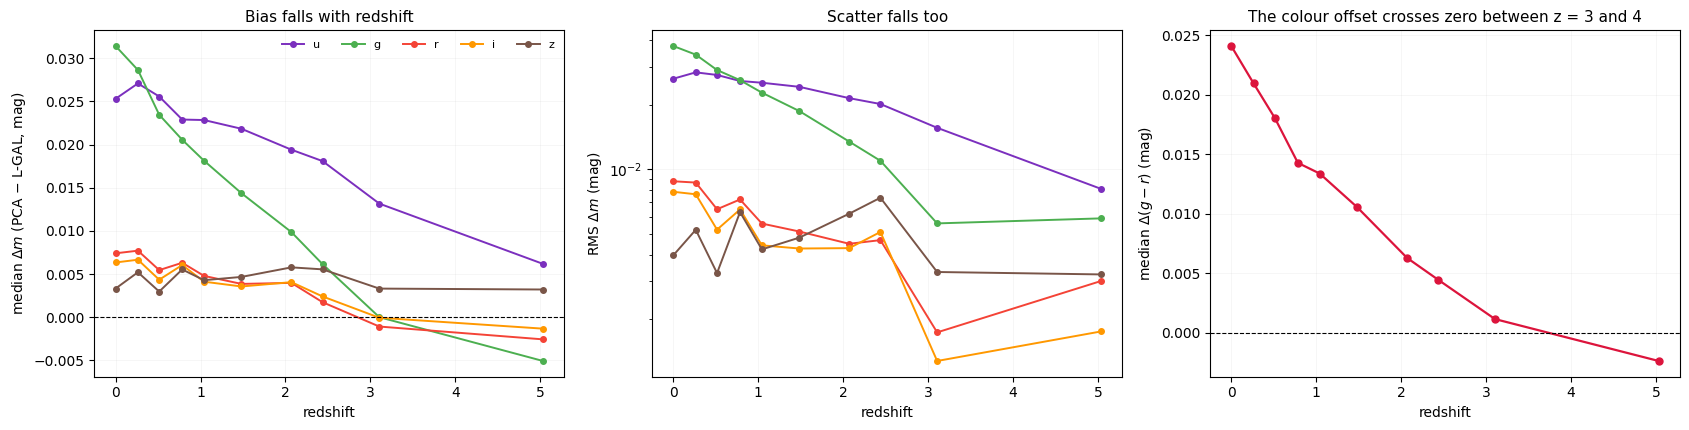

In [15]:
z_all = np.array([DATA[t]['snap'].z_planck for t in TAGS])
med   = {b: [] for b in BANDS}
rms   = {b: [] for b in BANDS}
d_gr  = []

for t in TAGS:
    d = DATA[t]
    for b in BANDS:
        delta = d['synth'][b] - d['lgal_mag'][:, BAND_IDX[b]]
        ok = np.isfinite(delta) & (d['lgal_mag'][:, BAND_IDX[b]] < 90.0)
        med[b].append(np.median(delta[ok])); rms[b].append(np.sqrt(np.mean(delta[ok] ** 2)))
    gr_in = d['synth']['g'] - d['synth']['r']
    gr_lg = d['lgal_mag'][:, 1] - d['lgal_mag'][:, 2]
    ok = np.isfinite(gr_in) & (d['lgal_mag'][:, 2] < 90.) & (d['lgal_mag'][:, 1] < 90.)
    d_gr.append(np.median(gr_in[ok] - gr_lg[ok]))

print(f'{"z":>7}{"N":>9}' + ''.join(f'{b:>10}' for b in BANDS) + f'{"d(g-r)":>10}')
print('-' * 68)
for k, t in enumerate(TAGS):
    print(f'{z_all[k]:>7.3f}{DATA[t]["n"]:>9,}'
          + ''.join(f'{med[b][k]:>10.4f}' for b in BANDS) + f'{d_gr[k]:>10.4f}')

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
for b in BANDS:
    axes[0].plot(z_all, med[b], 'o-', ms=4, lw=1.4, color=BAND_COLORS[b], label=b)
    axes[1].plot(z_all, rms[b], 'o-', ms=4, lw=1.4, color=BAND_COLORS[b], label=b)
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_ylabel(r'median $\Delta m$ (PCA $-$ L-GAL, mag)')
axes[0].set_title('Bias falls with redshift', fontsize=11)
axes[1].set_yscale('log'); axes[1].set_ylabel(r'RMS $\Delta m$ (mag)')
axes[1].set_title('Scatter falls too', fontsize=11)
axes[2].plot(z_all, d_gr, 'o-', ms=5, lw=1.6, color='crimson')
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_ylabel(r'median $\Delta(g-r)$ (mag)')
axes[2].set_title('The colour offset crosses zero between z = 3 and 4', fontsize=11)
for ax in axes:
    ax.set_xlabel('redshift'); ax.grid(alpha=0.2, lw=0.4)
axes[0].legend(fontsize=8, frameon=False, ncol=5)
fig.tight_layout(); plt.show()

The agreement **improves monotonically with redshift**, in every band. The *g*-band median
falls from +0.031 mag at z = 0 to about −0.005 at z = 5, and the $\Delta(g-r)$ colour offset
from +0.024 to −0.002, crossing zero between z = 3 and z = 4 (it is +0.0011 at
z = 3.11 and −0.0024 at z = 5.03).

That is the behaviour notebook 02 predicts. §4.1 and §7 there show the basis is at its most
accurate for **young** stellar populations and at its worst for old, metal-rich ones,
because the far-UV of an old population sits below the residual the fit leaves behind. A
z = 5 galaxy has had barely a gigayear to form stars; a z = 0 galaxy carries 13 Gyr of them.
So the population that reconstructs worst is exactly the one that dominates at low
redshift, and the trend above is that effect seen through real star-formation histories
rather than through the SSP library.

Two caveats worth keeping.

**The high-redshift samples are small.** 380 galaxies survive the resolution cuts at
z = 5.03 against 11,396 at z = 0, so the last point carries much more sampling noise than
the first, and these are different galaxies at each snapshot rather than one population
traced through time.

**This is not the colour bias.** The offsets here are hundredths of a magnitude between two
representations of the *same* L-GALAXIES calculation. The colour bias in
`documents/validation_by_colour.md` is a much larger disagreement between two different
BC03 products, and `documents/error_vs_bytes.md` §5 shows the basis contributes 0.9 % of it.

---

## What to take away

1. **The in-code C path works at every snapshot**, not only the one it was checked at.
   Median offsets stay within a few hundredths of a magnitude across 0 < z < 5, and the
   z = 0 numbers reproduce notebook 09's exactly.
2. **The agreement gets better with redshift**, because younger populations reconstruct
   better — the prediction of notebook 02 §4.1, confirmed on galaxies.
3. **The colour-colour locus tracks the model's own** at every redshift; the reconstruction
   is not distorting the shape of the population, only shifting it slightly.

**Related rungs:** `09_incode_pca_verification.ipynb` goes deeper at a single snapshot,
including the comparison against the Python post-processing path;
`11_multiz_sed_explorer.ipynb` covers individual galaxies and the observer frame;
`02_ssp_library_and_pca_basis.ipynb` §4.1 and §7 explain why age drives the accuracy.